# The Named Transformations

**This notebook is self-contained; it recaps how a matrix moves points before cataloguing the standard ones.**

Rotation, reflection, scaling, shear, projection, each is just a matrix, and each does something you can see. Recall from the previous notebook that **the columns of $A$ are where the unit vectors $\hat{\imath}$ and $\hat{\jmath}$ land**, so each matrix below can be read directly as a picture. We push one deliberately lopsided shape through every one of them, then ask which transformations preserve length and what happens when you apply two in a row.

## Learning objectives

- Match each named matrix, identity, scaling, rotation, reflection, shear, projection, permutation, to its geometric effect.
- Identify which transformations **preserve length** (the orthogonal ones).
- Show that applying two transformations in a row is the **product** of their matrices, and that the **order matters**.

## Background

Every matrix below is built by deciding where $\hat{\imath}$ and $\hat{\jmath}$ go and stacking those images as columns. The most useful one to know by heart is **rotation by angle $\theta$**:

$$R(\theta) = \begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}$$

A transformation **preserves length** ($\lVert A\mathbf{x}\rVert = \lVert\mathbf{x}\rVert$ for every $\mathbf{x}$) exactly when $A^{\top}A = I$; such a matrix is called **orthogonal**. Rotations and reflections are orthogonal; scalings, shears, and projections are not.

## This notebook covers

1. The catalogue: one shape under each named matrix.
2. Which ones preserve length, measured, not asserted.
3. Composition: two transformations in a row, and why the order matters.

**Prerequisites:** `U2-4_Transformations-1_MatrixAsMap`

**Dataset:** none, matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# an "F" outline: deliberately asymmetric, so a reflection is impossible to miss
F = np.array([[0.0, 0.0], [0.0, 1.0], [0.6, 1.0], [0.6, 0.8], [0.2, 0.8],
              [0.2, 0.6], [0.5, 0.6], [0.5, 0.4], [0.2, 0.4], [0.2, 0.0],
              [0.0, 0.0]]).T          # 2 x n: each COLUMN is a point, so A @ F transforms them all

def draw_shape(ax, pts, color, label=None, alpha=1.0, lw=2):
    ax.plot(pts[0], pts[1], color=color, label=label, alpha=alpha, lw=lw)
    ax.fill(pts[0], pts[1], color=color, alpha=0.15 * alpha)

## 1. The catalogue

Each panel shows the original shape (cyan) and its image (red) under one named matrix. Read each matrix's columns and check them against the picture, the first column is where the arrow pointing right ends up, the second is where the arrow pointing up ends up.

| Name | Matrix | What it does |
|---|---|---|
| Identity | $\begin{bmatrix}1&0\\0&1\end{bmatrix}$ | nothing, every point stays put |
| Scaling | $\begin{bmatrix}2&0\\0&0.5\end{bmatrix}$ | stretch $x$, squash $y$ |
| Rotation (45°) | $\begin{bmatrix}\cos45° & -\sin45°\\ \sin45° & \cos45°\end{bmatrix}$ | turn about the origin |
| Reflection | $\begin{bmatrix}-1&0\\0&1\end{bmatrix}$ | flip across the $y$-axis |
| Shear | $\begin{bmatrix}1&1\\0&1\end{bmatrix}$ | slide the top sideways |
| Projection | $\begin{bmatrix}1&0\\0&0\end{bmatrix}$ | flatten everything onto the $x$-axis |
| Permutation | $\begin{bmatrix}0&1\\1&0\end{bmatrix}$ | swap the coordinates (flip across $y=x$) |

The **projection** is worth a second look: it destroys information. Everything lands on a line, and once flattened there is no way to tell which point it came from. That irreversibility comes back in the next section as $\det = 0$.

**One familiar move is missing from the table: translation**, sliding every point two steps to the right, say. It is not there because **no $2\times2$ matrix can do it.** Every matrix sends $\mathbf{0}$ to $\mathbf{0}$ (multiplying any matrix by the zero vector gives the zero vector), so a linear transformation always pins the origin in place. Sliding the plane moves the origin, so it is *not* a linear transformation, it is called an **affine** one. Graphics systems get around this by working in three coordinates instead of two, which is how a single matrix ends up able to rotate *and* translate; that trick is beyond this unit.

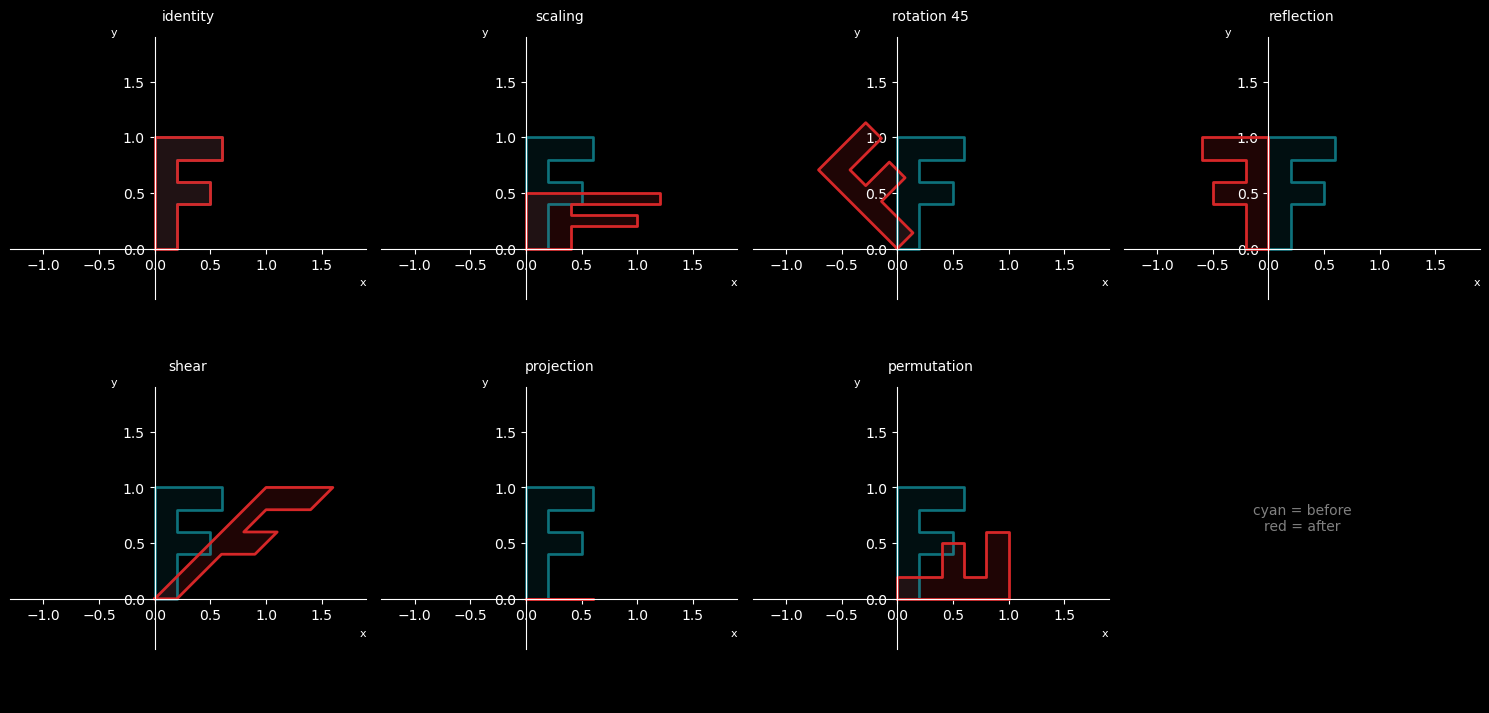

In [2]:
theta = np.radians(45)

transforms = [
    ("identity",     np.array([[1, 0], [0, 1]])),
    ("scaling",      np.array([[2, 0], [0, 0.5]])),
    ("rotation 45",  np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])),
    ("reflection",   np.array([[-1, 0], [0, 1]])),
    ("shear",        np.array([[1, 1], [0, 1]])),
    ("projection",   np.array([[1, 0], [0, 0]])),
    ("permutation",  np.array([[0, 1], [1, 0]])),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for ax, (name, M) in zip(axes.flat, transforms):
    draw_shape(ax, F, "tab:cyan", alpha=0.55)
    draw_shape(ax, M @ F, "tab:red")
    center_axes(ax); label_axes(ax)
    ax.set_xlim(-1.3, 1.9); ax.set_ylim(-0.45, 1.9); ax.set_aspect("equal")
    ax.set_title(name, pad=12, fontsize=10)

axes.flat[-1].axis("off")          # 7 transforms in an 8-panel grid
axes.flat[-1].text(0.5, 0.5, "cyan = before\nred = after", ha="center", va="center", color="gray")
plt.tight_layout()
plt.show()

In [3]:
# print each matrix next to its name, so the columns can be checked against the pictures
for name, M in transforms:
    helpers.show(np.round(M, 3), label=name)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. Which ones preserve length?

A transformation **preserves length** if every arrow comes out exactly as long as it went in. Rotating a shape doesn't change its size; shearing it does. Rather than take that on faith, we measure: push a batch of unit-length vectors through each matrix and check whether they are still unit length afterwards.

The algebraic test is $A^{\top}A = I$, and matrices passing it are called **orthogonal**. Watch that the two tests agree.

In [4]:
# a fan of unit-length vectors to push through each transformation
angles = np.linspace(0, 2 * np.pi, 200, endpoint=False)
unit = np.array([np.cos(angles), np.sin(angles)])     # 2 x 200, each column a unit vector

for name, M in transforms:
    lengths = np.linalg.norm(M @ unit, axis=0)
    keeps_length = np.allclose(lengths, 1)
    is_orthogonal = np.allclose(M.T @ M, np.eye(2))
    print(f"{name:<13} lengths {lengths.min():.2f}-{lengths.max():.2f}"
          f"   preserves length: {str(keeps_length):<5}   A^T A = I: {is_orthogonal}")

identity      lengths 1.00-1.00   preserves length: True    A^T A = I: True
scaling       lengths 0.50-2.00   preserves length: False   A^T A = I: False
rotation 45   lengths 1.00-1.00   preserves length: True    A^T A = I: True
reflection    lengths 1.00-1.00   preserves length: True    A^T A = I: True
shear         lengths 0.62-1.62   preserves length: False   A^T A = I: False
projection    lengths 0.00-1.00   preserves length: False   A^T A = I: False
permutation   lengths 1.00-1.00   preserves length: True    A^T A = I: True


Rotation, reflection, and permutation come through with every length still exactly 1, and they are precisely the three that satisfy $A^{\top}A = I$. The geometric test and the algebraic test agree, which is what "orthogonal" means.

Notice the projection's minimum length is $0$: some vectors are annihilated entirely.

## 3. Order matters

Applying transformation $B$ and then $A$ is the same as applying the single matrix $AB$, the product, with the *first* transformation on the *right*. (That right-to-left order looks backwards until you write it out: $A(B\mathbf{x}) = (AB)\mathbf{x}$.)

And since matrix multiplication is **not commutative**, swapping the order genuinely changes the result. Rotate-then-reflect and reflect-then-rotate land the shape in two different places.

In [5]:
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])     # rotate 45 degrees
Fl = np.array([[-1, 0], [0, 1]])                    # reflect across the y-axis

helpers.show(np.round(Fl @ R, 3), label="reflect after rotating")
helpers.show(np.round(R @ Fl, 3), label="rotate after reflecting")
print("same matrix?", np.allclose(Fl @ R, R @ Fl))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

same matrix? False


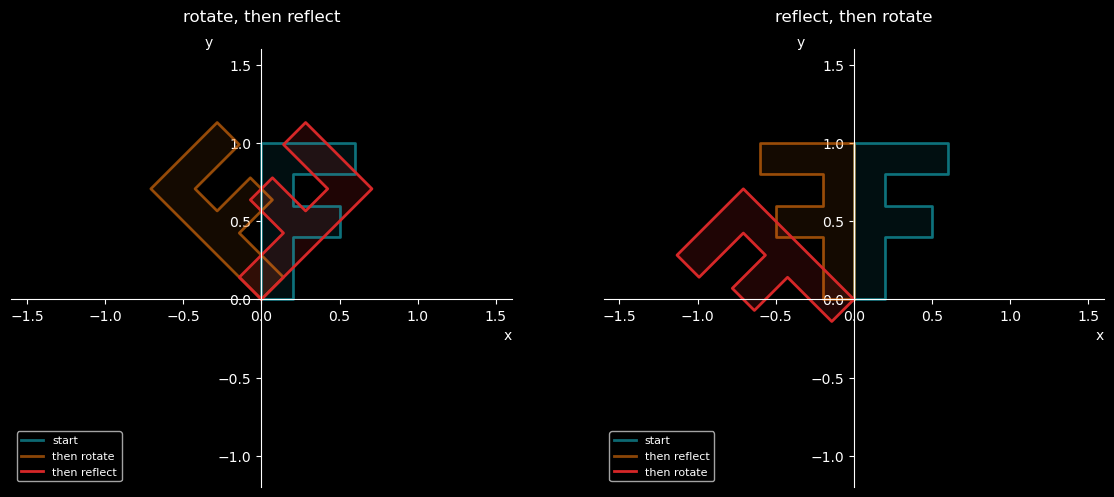

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

draw_shape(axes[0], F, "tab:cyan", "start", alpha=0.55)
draw_shape(axes[0], R @ F, "tab:orange", "then rotate", alpha=0.55)
draw_shape(axes[0], Fl @ R @ F, "tab:red", "then reflect")
axes[0].set_title("rotate, then reflect", pad=20)

draw_shape(axes[1], F, "tab:cyan", "start", alpha=0.55)
draw_shape(axes[1], Fl @ F, "tab:orange", "then reflect", alpha=0.55)
draw_shape(axes[1], R @ Fl @ F, "tab:red", "then rotate")
axes[1].set_title("reflect, then rotate", pad=20)

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.2, 1.6); ax.set_aspect("equal")
    ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

The two red shapes end up in different places. That is $AB \neq BA$, the non-commutativity you met algebraically with matrix products, showing up as a fact about the world: turning then flipping is not the same as flipping then turning.

## 4. Summary

- Each named transformation is just a matrix whose **columns say where $\hat{\imath}$ and $\hat{\jmath}$ land**.
- **Rotation, reflection, and permutation preserve length**: equivalently $A^{\top}A = I$, the definition of **orthogonal**. Scaling, shear, and projection do not.
- **Projection destroys information**: everything collapses onto a line and cannot be undone. That collapse is what $\det = 0$ measures in the next section.
- Two transformations in a row = the **product** of their matrices, first one on the right; **order matters** because $AB \neq BA$.

Next: watching the deformation happen continuously (`U2-4_Transformations-3_UnitCircleAnimation`).